# Telco Customer Churn Prediction
### End-to-End Machine Learning Project
**Dataset:** IBM Telco Customer Churn
**Author:** (Shrouk yasser)


## Business Understanding

### Context

A telecom company is losing customers every month.   
The company wants to **identify at-risk customers early** so the retention team can offer promotions before they leave.

---

### Business Questions

**Q1.** What are the most important customer characteristics that predict churn?  
*(demographics, services subscribed, contract type)*

**Q2.** Which contract type and payment method are most associated with high churn rates?

**Q3.** Do customers who subscribe to more add-on services churn less than those who don't?


---


# Data Understanding

In [36]:
# Import Necessary Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')

# Load Data

In [37]:
pd.set_option('display.max_columns', None)

In [38]:
df = pd.read_csv('telco_churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Data Cleaning Step

### 1 - Check Data Types

In [39]:
# Check Data Types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### 2 - Check Missing Values

In [40]:

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
round((df.isna().mean()) * 100, 2)

customerID          0.00
gender              0.00
SeniorCitizen       0.00
Partner             0.00
Dependents          0.00
tenure              0.00
PhoneService        0.00
MultipleLines       0.00
InternetService     0.00
OnlineSecurity      0.00
OnlineBackup        0.00
DeviceProtection    0.00
TechSupport         0.00
StreamingTV         0.00
StreamingMovies     0.00
Contract            0.00
PaperlessBilling    0.00
PaymentMethod       0.00
MonthlyCharges      0.00
TotalCharges        0.16
Churn               0.00
dtype: float64

In [41]:
# Blank TotalCharges belong to new customers with tenure=0 → fill with 0
df['TotalCharges'].fillna(0, inplace=True)
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### 3 - Check Outliers

In [42]:
from sklearn.preprocessing import LabelEncoder

numeric_lst = df.select_dtypes(include='number').columns
for col in numeric_lst:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    print(col)
    print(f'  Outliers count : {len(outliers)}  ')
    print('_' * 30)

SeniorCitizen
  Outliers count : 1142  
______________________________
tenure
  Outliers count : 0  
______________________________
MonthlyCharges
  Outliers count : 0  
______________________________
TotalCharges
  Outliers count : 0  
______________________________


In [43]:
# Drop customerID — unique identifier with no predictive value
df.drop('customerID', axis=1, inplace=True)

# Encode target: Yes → 1  |  No → 0
df['Churn'] = (df['Churn'] == 'Yes').astype(int)
df['Churn'].value_counts()


Churn
0    5174
1    1869
Name: count, dtype: int64

In [44]:
# Remove duplicates
df.drop_duplicates(inplace=True, ignore_index=True)
df.duplicated().sum()

0

# Exploratory Data Analysis (EDA)

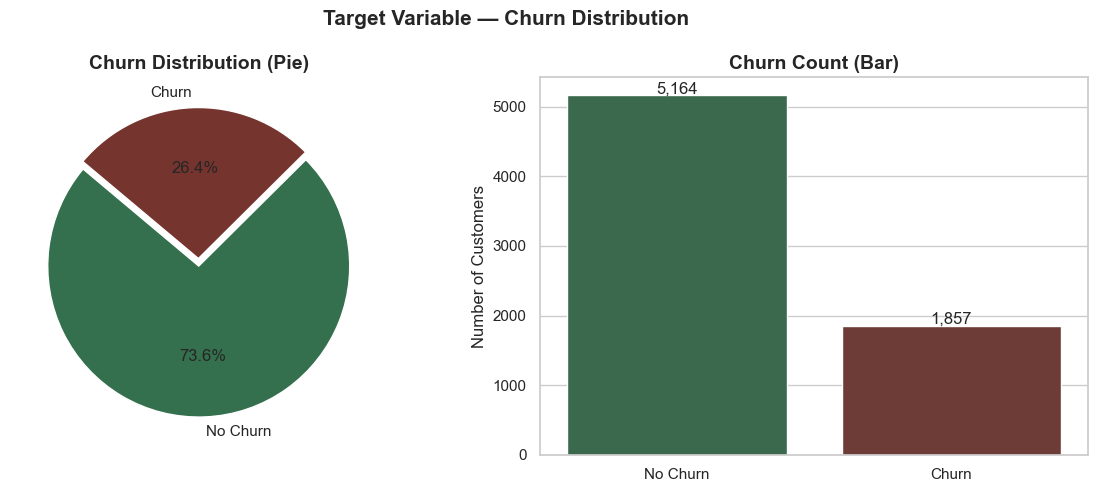

In [45]:
# ── PLOT 1: Churn Distribution 
churn_counts = df['Churn'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie(churn_counts, labels=['No Churn', 'Churn'],
            autopct='%1.1f%%', startangle=140,
            colors=["#34704D",  "#76342E" ], explode=(0, 0.05))
axes[0].set_title('Churn Distribution (Pie)', fontsize=14, fontweight='bold')

sns.barplot(x=['No Churn', 'Churn'], y=churn_counts.values,
            palette=["#34704D",  "#76342E"], ax=axes[1])
axes[1].set_title('Churn Count (Bar)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Customers')
for p in axes[1].patches:
    axes[1].annotate(f"{int(p.get_height()):,}",
                    (p.get_x() + p.get_width() / 2, p.get_height() + 30),
                    ha='center', fontsize=12)

plt.suptitle('Target Variable — Churn Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

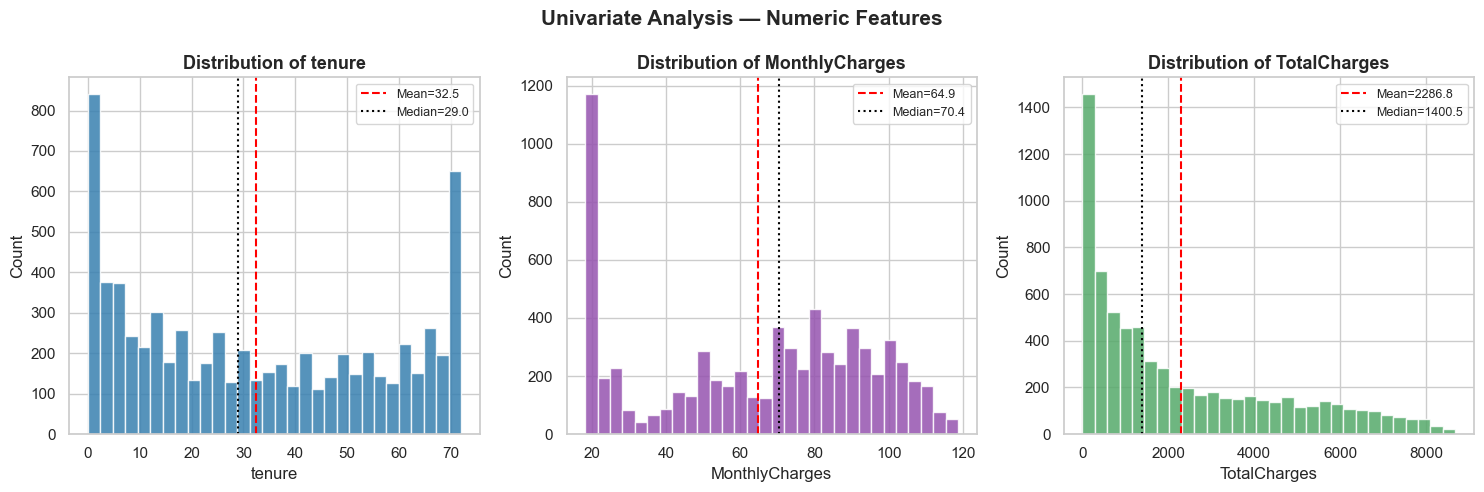

In [46]:
# ── PLOT 2: Histograms — Numeric Feature Distributions 
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
colors = ["#3880b0", "#9553AF", "#55a96a"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col, color in zip(axes, numeric_cols, colors):
    ax.hist(df[col], bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(),   color='red',   linestyle='--', label=f'Mean={df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='black', linestyle=':',  label=f'Median={df[col].median():.1f}')
    ax.set_title(f'Distribution of {col}', fontsize=13, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

plt.suptitle('Univariate Analysis — Numeric Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()



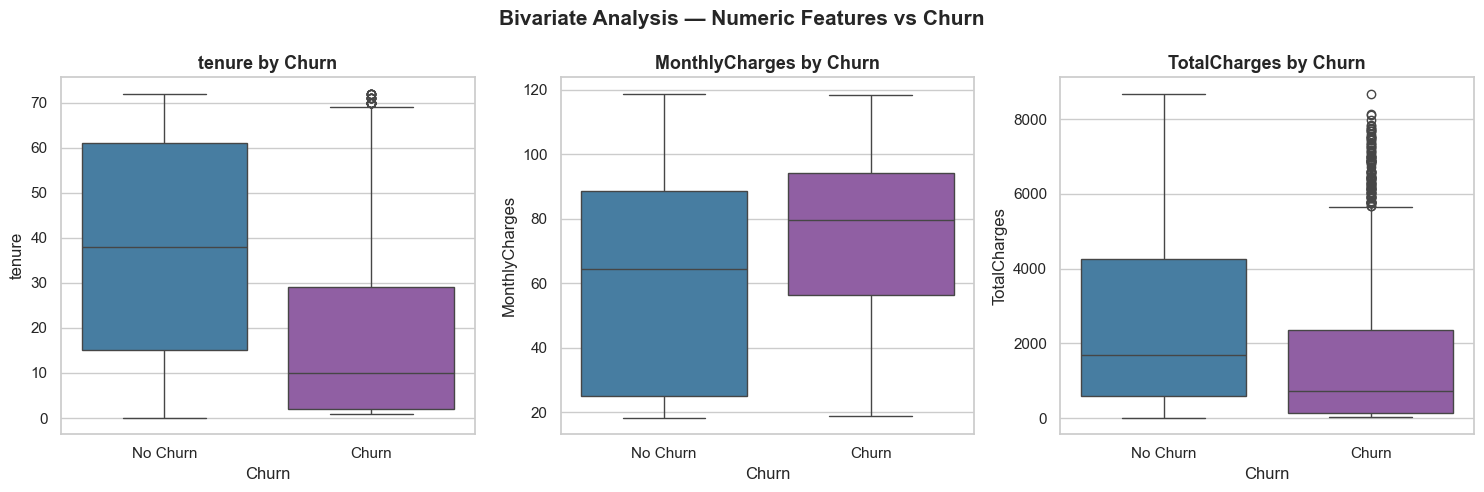

In [47]:
# PLOT 3: Box Plots — Numeric Features vs Churn 
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(x='Churn', y=col, data=df, palette=["#3880b0" , "#9553AF"], ax=ax)
    ax.set_xticklabels(['No Churn', 'Churn'])
    ax.set_title(f'{col} by Churn', fontsize=13, fontweight='bold')
    mean_no  = df[df['Churn']==0][col].mean()
    mean_yes = df[df['Churn']==1][col].mean()

plt.suptitle('Bivariate Analysis — Numeric Features vs Churn', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

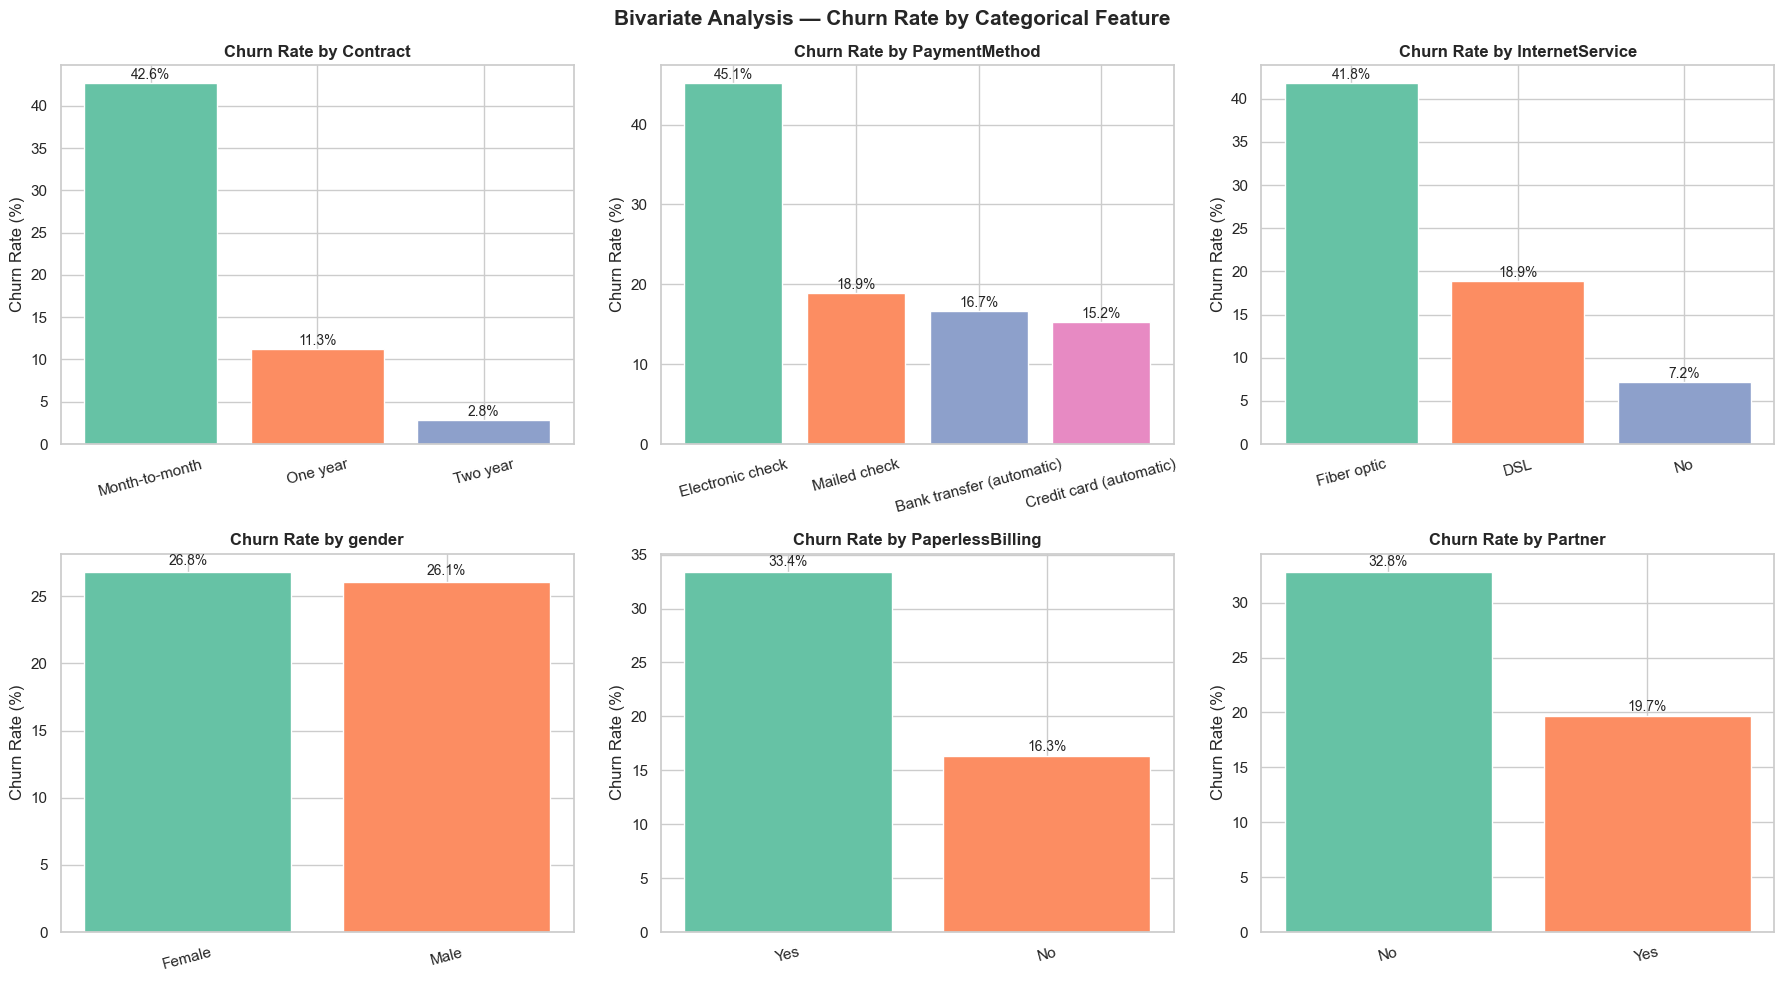

In [48]:
#  PLOT 4: Bar Charts — Categorical Features vs Churn 
cat_analysis_cols = ['Contract', 'PaymentMethod', 'InternetService',
                    'gender', 'PaperlessBilling', 'Partner']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_analysis_cols):
    churn_rate = df.groupby(col)['Churn'].mean().sort_values(ascending=False) * 100
    bars = axes[i].bar(churn_rate.index, churn_rate.values,
                    color=sns.color_palette('Set2', len(churn_rate)))
    axes[i].set_title(f'Churn Rate by {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, churn_rate.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{val:.1f}%', ha='center', fontsize=10)


plt.suptitle('Bivariate Analysis — Churn Rate by Categorical Feature', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

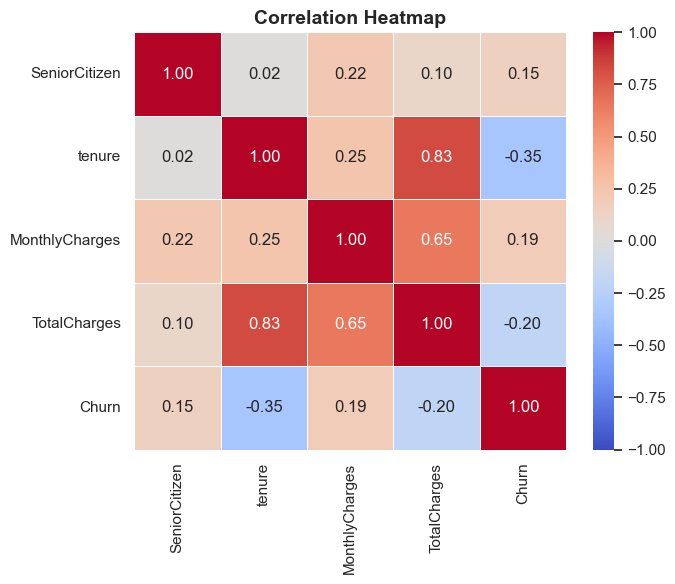

In [49]:
#  PLOT 5: Correlation Heatmap 
corr_df     = df[['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Feature Engineering

In [50]:
# Create tenure_group based on how long the customer has been with the company
def tenure_group(x):
    if x <= 12:
        return 'New Customer'
    elif x <= 36:
        return 'Mid-term Customer'
    else:
        return 'Long-term Customer'

df['tenure'].apply(tenure_group).value_counts()

tenure
Long-term Customer    3001
New Customer          2164
Mid-term Customer     1856
Name: count, dtype: int64

In [51]:
df['tenure_group'] = df['tenure'].apply(tenure_group)
df['tenure_group'].value_counts()

tenure_group
Long-term Customer    3001
New Customer          2164
Mid-term Customer     1856
Name: count, dtype: int64

In [52]:
# Revenue efficiency metric: how much does the customer pay per month of tenure
df['ChargesPerTenure'] = df['TotalCharges'] / (df['tenure'] + 1)
print(f"ChargesPerTenure — Mean: {df['ChargesPerTenure'].mean():.2f}  |  Std: {df['ChargesPerTenure'].std():.2f}")

ChargesPerTenure — Mean: 59.12  |  Std: 30.54


In [53]:
# Count of premium add-on services subscribed
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']

df['NumServices'] = df[service_cols].apply(lambda row: (row == 'Yes').sum(), axis=1)
df['NumServices'].value_counts().sort_index()

NumServices
0    2197
1     966
2    1033
3    1118
4     852
5     571
6     284
Name: count, dtype: int64

### Save cleaned dataframe for later use in Streamlit deployment

In [54]:
df.to_csv('cleaned_telco.csv')

# Data Preprocessing

# Data Preprocessing Steps for Machine Learning :

* 1- Split Data into Input Features and Target Column

* 2- Split Data into Train & Test

* 3- Numerical Cols : Impute Missing → Scaling

* 4- Categorical Cols : Impute Missing → Encoding

* 7- Handle Imbalance (SMOTE)

### 1 - Split Data into Input Features and Target Feature

In [55]:
x = df.drop('Churn', axis=1)
y = df['Churn']
df['Churn'].value_counts()

Churn
0    5164
1    1857
Name: count, dtype: int64

## Numerical Pipeline

In [56]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

si = SimpleImputer(strategy='mean')
sc = StandardScaler()

num_pipeline = Pipeline([('Imputer', si), ('Scaling', sc)])
num_pipeline

Pipeline(steps=[('Imputer', SimpleImputer()), ('Scaling', StandardScaler())])

## Categorical Pipeline — One Hot Encoding

In [57]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(drop='first', sparse_output=False)

ohe_pipeline = Pipeline([('OHE Pipeline', ohe)])
ohe_pipeline

Pipeline(steps=[('OHE Pipeline',
                 OneHotEncoder(drop='first', sparse_output=False))])

### Ordinal Pipeline — tenure_group

In [58]:
from sklearn.preprocessing import OrdinalEncoder
ord_enc = OrdinalEncoder(categories=[['New Customer', 'Mid-term Customer', 'Long-term Customer']])
ord_pipeline = Pipeline([('Ordinal Pipeline', ord_enc)])
ord_pipeline

Pipeline(steps=[('Ordinal Pipeline',
                 OrdinalEncoder(categories=[['New Customer',
                                             'Mid-term Customer',
                                             'Long-term Customer']]))])

### Assign each column to the corresponding Pipeline

In [59]:
num_cols = x.select_dtypes(include='number').columns
num_cols

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'ChargesPerTenure', 'NumServices'],
      dtype='object')

In [60]:
ohe_cols = x.select_dtypes(include='object').columns.drop('tenure_group')
ohe_cols

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [61]:
from sklearn.compose import ColumnTransformer

Preprocessing = ColumnTransformer(transformers=[
    ('Numerical',   num_pipeline, num_cols),
    ('OHE',         ohe_pipeline, ohe_cols),
    ('Ordinal',     ord_pipeline, ['tenure_group'])
])
Preprocessing

ColumnTransformer(transformers=[('Numerical',
                                 Pipeline(steps=[('Imputer', SimpleImputer()),
                                                 ('Scaling',
                                                  StandardScaler())]),
                                 Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'ChargesPerTenure', 'NumServices'],
      dtype='object')),
                                ('OHE',
                                 Pipeline(steps=[('OHE Pipeline',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False))]),
                                 Index(['gender', 'Partner',...ltipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')),
                                ('Ordinal',
                                 Pipeline(steps=[('Ordinal Pipeline',
                                                  OrdinalEncoder(categories=[['New '
                                                                              'Customer',
                                                                              'Mid-term '
                                                                              'Customer',
                                                                              'Long-term '
                                                                              'Customer']]))]),
                                 ['tenure_group'])])

In [62]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

models = [
    ('Logistic Regression',  LogisticRegression(random_state=42, max_iter=1000 )),
    ('Random Forest',        RandomForestClassifier(random_state=42 )),
    ('Gradient Boosting',    GradientBoostingClassifier(random_state=42)),
    ('XGBoost',              XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0))
]

scoring  = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
all_results = []

for name, model in models:
    model_pipeline = ImbPipeline(steps=[
        ('Preprocessing', Preprocessing),
        ('SMOTE',         SMOTE(random_state=42)),
        ('Model',         model)
    ])

    result = cross_validate(model_pipeline, x, y, scoring=scoring,
                            cv=5, return_train_score=True, n_jobs=-1)

    row = {
        'Model':          name,
        'Train Accuracy': round(result['train_accuracy'].mean() * 100, 2),
        'Test Accuracy':  round(result['test_accuracy'].mean()  * 100, 2),
        'Precision':      round(result['test_precision'].mean() * 100, 2),
        'Recall':         round(result['test_recall'].mean()    * 100, 2),
        'F1':             round(result['test_f1'].mean()        * 100, 2),
        'ROC-AUC':        round(result['test_roc_auc'].mean()   * 100, 2),
    }
    all_results.append(row)

    print(name)
    print(f'  Train Accuracy : {row["Train Accuracy"]}%')
    print(f'  Test Accuracy  : {row["Test Accuracy"]}%')
    print(f'  Precision      : {row["Precision"]}%')
    print(f'  Recall         : {row["Recall"]}%')
    print(f'  F1             : {row["F1"]}%')
    print(f'  ROC-AUC        : {row["ROC-AUC"]}%')
    print('-' * 50)

Logistic Regression
  Train Accuracy : 75.95%
  Test Accuracy  : 75.66%
  Precision      : 52.67%
  Recall         : 79.16%
  F1             : 63.24%
  ROC-AUC        : 84.68%
--------------------------------------------------
Random Forest
  Train Accuracy : 99.8%
  Test Accuracy  : 78.21%
  Precision      : 59.18%
  Recall         : 56.97%
  F1             : 58.05%
  ROC-AUC        : 82.41%
--------------------------------------------------
Gradient Boosting
  Train Accuracy : 80.79%
  Test Accuracy  : 78.59%
  Precision      : 58.44%
  Recall         : 66.29%
  F1             : 62.1%
  ROC-AUC        : 84.33%
--------------------------------------------------
XGBoost
  Train Accuracy : 93.27%
  Test Accuracy  : 77.82%
  Precision      : 58.51%
  Recall         : 55.9%
  F1             : 57.16%
  ROC-AUC        : 82.33%
--------------------------------------------------


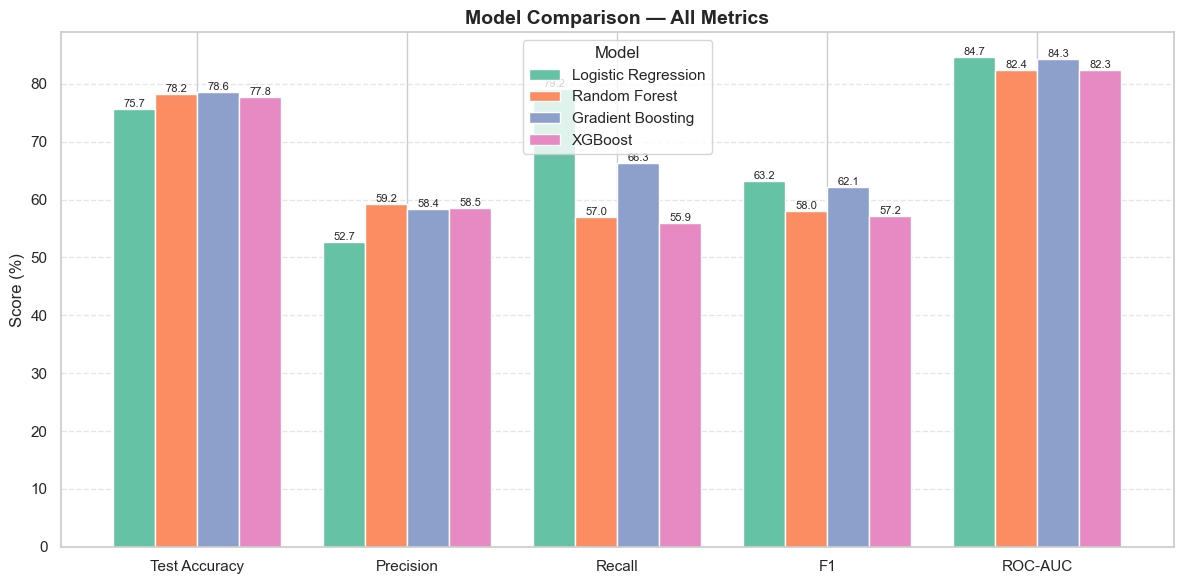

In [63]:
results_df = pd.DataFrame(all_results)

plot_df = results_df.set_index('Model')[['Test Accuracy',
                                        'Precision',
                                        'Recall',
                                        'F1',
                                        'ROC-AUC']].T

ax = plot_df.plot(
    kind='bar',
    figsize=(12,6),
    width=0.8
)

plt.title('Model Comparison — All Metrics', fontsize=14, fontweight='bold')
plt.xlabel('')
plt.ylabel('Score (%)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', fontsize=8)

plt.tight_layout()
plt.show()

In [64]:
from sklearn.model_selection import GridSearchCV

model_pipeline = ImbPipeline(steps=[
    ('Preprocessing', Preprocessing),
    ('SMOTE', SMOTE(random_state=42)),
    ('Model', LogisticRegression(random_state=42, max_iter=1000))
])

params = {
    'Model__C': [0.01, 0.1, 1, 10],
    'Model__solver': ['liblinear', 'lbfgs']
}

grid_search = GridSearchCV(
    estimator=model_pipeline,
    param_grid=params,
    scoring='roc_auc',
    cv=5,
    return_train_score=True,
    n_jobs=-1
)

grid_search.fit(x, y)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('Preprocessing',
                                        ColumnTransformer(transformers=[('Numerical',
                                                                         Pipeline(steps=[('Imputer',
                                                                                          SimpleImputer()),
                                                                                         ('Scaling',
                                                                                          StandardScaler())]),
                                                                         Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'ChargesPerTenure', 'NumServices'],
      dtype='object')),
                                                                        ('OHE',
                                                                         Pipeline(steps=[('OHE '
                                                                                          'Pipeline',
                                                                                          OneHotEncoder(...
                                                                                          'Pipeline',
                                                                                          OrdinalEncoder(categories=[['New '
                                                                                                                      'Customer',
                                                                                                                      'Mid-term '
                                                                                                                      'Customer',
                                                                                                                      'Long-term '
                                                                                                                      'Customer']]))]),
                                                                         ['tenure_group'])])),
                                       ('SMOTE', SMOTE(random_state=42)),
                                       ('Model',
                                        LogisticRegression(max_iter=1000,
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'Model__C': [0.01, 0.1, 1, 10],
                         'Model__solver': ['liblinear', 'lbfgs']},
             return_train_score=True, scoring='roc_auc')

In [65]:
grid_search.best_score_

0.8469646671701703

In [66]:
grid_search.best_params_

{'Model__C': 0.1, 'Model__solver': 'lbfgs'}

In [67]:
best_params = grid_search.best_params_

final_pipeline = ImbPipeline(steps=[
    ('Preprocessing', Preprocessing),
    ('SMOTE', SMOTE(random_state=42)),
    ('Model', LogisticRegression(
        C=best_params['Model__C'],
        solver=best_params['Model__solver'],
        max_iter=1000,
        random_state=42
    ))
])

final_pipeline.fit(x, y)

Pipeline(steps=[('Preprocessing',
                 ColumnTransformer(transformers=[('Numerical',
                                                  Pipeline(steps=[('Imputer',
                                                                   SimpleImputer()),
                                                                  ('Scaling',
                                                                   StandardScaler())]),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'ChargesPerTenure', 'NumServices'],
      dtype='object')),
                                                 ('OHE',
                                                  Pipeline(steps=[('OHE '
                                                                   'Pipeline',
                                                                   OneHotEncoder(drop='first',
                                                                                 sparse_output=F...
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')),
                                                 ('Ordinal',
                                                  Pipeline(steps=[('Ordinal '
                                                                   'Pipeline',
                                                                   OrdinalEncoder(categories=[['New '
                                                                                               'Customer',
                                                                                               'Mid-term '
                                                                                               'Customer',
                                                                                               'Long-term '
                                                                                               'Customer']]))]),
                                                  ['tenure_group'])])),
                ('SMOTE', SMOTE(random_state=42)),
                ('Model',
                 LogisticRegression(C=0.1, max_iter=1000, random_state=42))])

In [68]:
import joblib

joblib.dump(final_pipeline, 'churn_model.pkl')

['churn_model.pkl']